# DINOv2 Embeddings — Feature Extraction for Model 2

This notebook extracts image embeddings from a locally saved **DINOv3** model
for all images in the labeled dataset.

The resulting embeddings are used to train **Model 2**: a Logistic Regression classifier
that distinguishes `good` nuclei from `invaginated` ones (applied only to nuclei
that passed Model 1 quality control).

**Input:** labeled dataset folder (4 classes)

**Pipeline:**
1. Load DINOv3 from local weights (GPU required)
2. Collect images from all four class folders
3. Extract the CLS token embedding (768-dim) for each image
4. Save embeddings, labels, and paths to a `.npz` file
5. Visualize the embedding space with PCA (2D)

**Classes:**
- `0` — good
- `1` — invaginated
- `2` — Unclassifiable
- `3` — trash

## 1. Setup — Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Imports

In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

import torch
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoModel, AutoImageProcessor
from sklearn.decomposition import PCA

## 3. Configuration

Set all paths here — nothing else in this notebook needs to change between runs.

In [3]:
# ── Dataset ────────────────────────────────────────────────────────────────
DATASET_DIR = "/content/drive/MyDrive/model_nuc/dataset v.0.4"  # ← change if needed

CLASS_DIRS = {
    0: f"{DATASET_DIR}/good",
    1: f"{DATASET_DIR}/invaginated",
    2: f"{DATASET_DIR}/Unclassifiable",
    3: f"{DATASET_DIR}/trash",
}
CLASS_NAMES = {0: "good", 1: "invaginated", 2: "Unclassifiable", 3: "trash"}

# ── Model weights (local path on Drive) ────────────────────────────────────
MODEL_DIR = "/content/drive/MyDrive/model_nuc/model_dinov3/dinov3_b16_weights"

# ── Output ─────────────────────────────────────────────────────────────────
OUTPUT_NPZ = "/content/drive/MyDrive/model_nuc/embeddings_dino.0.4.npz"

# ── Supported image extensions ─────────────────────────────────────────────
EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp", "*.tif", "*.tiff")

## 4. Load DINOv3 Model

Model is loaded from local Drive weights (no internet download required).
Requires GPU — go to Runtime → Change runtime type → GPU if this cell fails.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type != "cuda":
    raise RuntimeError("No GPU detected. Go to Runtime → Change runtime type → GPU.")

print(f"Device: {device}")

# Load model and processor from local weights
# trust_remote_code=True may be required for some custom checkpoints
try:
    model     = AutoModel.from_pretrained(MODEL_DIR).to(device).eval()
    processor = AutoImageProcessor.from_pretrained(MODEL_DIR)
except Exception as e:
    print(f"Standard load failed ({e}), retrying with trust_remote_code=True")
    model     = AutoModel.from_pretrained(MODEL_DIR, trust_remote_code=True).to(device).eval()
    processor = AutoImageProcessor.from_pretrained(MODEL_DIR, trust_remote_code=True)

print("✓ DINOv3 model loaded")

Device: cuda


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

✓ DINOv3 model loaded


## 5. Collect Images from Dataset

In [5]:
def collect_images(dir_path):
    """Return a sorted list of all image file paths in dir_path."""
    paths = []
    for ext in EXTENSIONS:
        paths.extend(glob.glob(os.path.join(dir_path, ext)))
    return sorted(paths)


all_paths  = []
all_labels = []

for label, dir_path in CLASS_DIRS.items():
    imgs = collect_images(dir_path)
    all_paths.extend(imgs)
    all_labels.extend([label] * len(imgs))
    print(f"  {CLASS_NAMES[label]:>15}: {len(imgs)} images")

all_labels = np.array(all_labels)
print(f"\n  Total: {len(all_paths)} images")

             good: 90 images
      invaginated: 60 images
   Unclassifiable: 95 images
            trash: 182 images

  Total: 427 images


## 6. Extract DINOv3 Embeddings

For each image we extract the **CLS token** from the last hidden state.
This 768-dimensional vector summarizes the global image content and is
used as input to Model 2.

In [6]:
@torch.no_grad()
def get_cls_embeddings(image_paths, batch_size=16):
    """
    Extract DINOv2 CLS token embeddings for a list of image paths.

    The CLS token (index 0 of last_hidden_state) provides a global
    summary of the image content — shape per image: (768,).

    Args:
        image_paths (list): List of image file paths.
        batch_size  (int):  Number of images processed per forward pass.

    Returns:
        numpy array of shape (N, 768)
    """
    all_embs = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting embeddings"):
        batch_paths = image_paths[i : i + batch_size]
        images = [Image.open(p).convert("RGB") for p in batch_paths]

        inputs  = processor(images=images, return_tensors="pt").to(device)
        outputs = model(**inputs)

        # last_hidden_state: (B, num_tokens, dim)
        # Token 0 is the CLS token — global image representation
        cls = outputs.last_hidden_state[:, 0, :]   # (B, 768)
        all_embs.append(cls.cpu().numpy())

    return np.vstack(all_embs)


X = get_cls_embeddings(all_paths, batch_size=16)
print(f"\n✓ Embeddings shape: {X.shape}")

Extracting embeddings:   0%|          | 0/27 [00:00<?, ?it/s]


✓ Embeddings shape: (427, 768)


## 7. Save Embeddings to Disk

In [7]:
# Save embeddings, integer labels, and source paths together in one .npz file.
# This file is the input for the Model 2 training notebook.
np.savez(
    OUTPUT_NPZ,
    X      = X,
    labels = all_labels,
    paths  = np.array(all_paths)
)
print(f"✓ Saved to: {OUTPUT_NPZ}")

✓ Saved to: /content/drive/MyDrive/model_nuc/embeddings_dino.0.4.npz


## 8. Visualize Embedding Space with PCA

Project the 768-dimensional embeddings to 2D.
A separation between `good` and `invaginated` clusters indicates
that DINOv2 features carry enough morphological signal for Model 2.

Explained variance: PC1=25.7%  PC2=9.6%


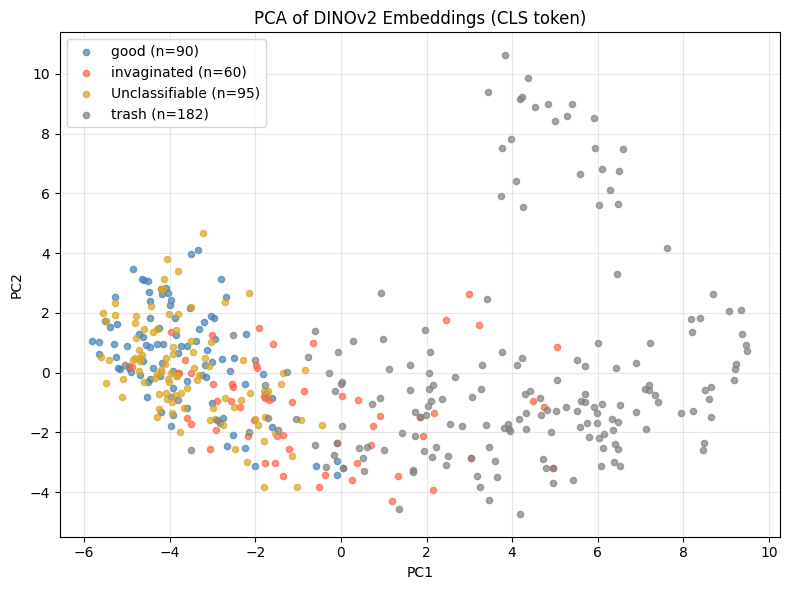

In [8]:
pca = PCA(n_components=2, random_state=0)
X2  = pca.fit_transform(X)
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}  "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")

COLORS = {0: "steelblue", 1: "tomato", 2: "goldenrod", 3: "gray"}

plt.figure(figsize=(8, 6))
for label, name in CLASS_NAMES.items():
    mask = all_labels == label
    plt.scatter(X2[mask, 0], X2[mask, 1],
                label=f"{name} (n={mask.sum()})",
                color=COLORS[label], alpha=0.7, s=20)

plt.title("PCA of DINOv2 Embeddings (CLS token)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()